# Root-Finding Methods in Python

Goal:
Implement and compare numerical methods for solving nonlinear equations.

Methods:
- Bisection
- Newton-Raphson
- Secant

Test Function:
f(x) = x^3 - x - 2

In [5]:
import numpy as np
import matplotlib.pyplot as plt

In [6]:
def f(x):
    return x**3 - x - 2

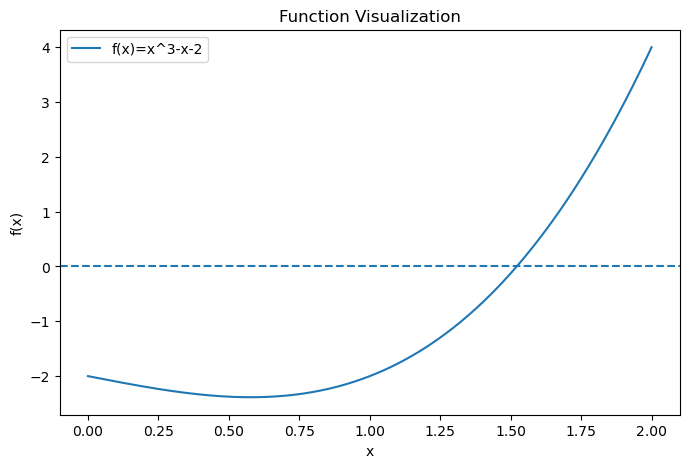

In [7]:
x = np.linspace(0, 2, 400)
y = f(x)

plt.figure(figsize=(8,5))
plt.plot(x, y, label='f(x)=x^3-x-2')
plt.axhline(0, linestyle='--')
plt.xlabel("x")
plt.ylabel("f(x)")
plt.title("Function Visualization")
plt.legend()
plt.show()

## Initial Observation

From the graph, the function crosses the x-axis between x = 1 and x = 2.

Also:

f(1) = -2  
f(2) = 4

Since the function changes sign between 1 and 2, a root exists in this interval.

Therefore, we choose the initial interval:

[1, 2]

In [10]:
def bisection(f, a, b, tol=1e-6, max_iter=100):
    if f(a) * f(b) >= 0:
        raise ValueError("Function must change sign over the interval.")

    results = []

    for i in range(max_iter):
        c = (a + b) / 2
        fc = f(c)

        results.append((i+1, a, b, c, fc))

        if abs(fc) < tol:
            return c, results

        if f(a) * fc < 0:
            b = c
        else:
            a = c

    return c, results

In [11]:
root_bisect, bisect_results = bisection(f, 1, 2)

print("Bisection root:", root_bisect)
print("f(root):", f(root_bisect))
print("Iterations:", len(bisect_results))

Bisection root: 1.5213797092437744
f(root): 1.4498129807805071e-08
Iterations: 22


In [12]:
import pandas as pd

bisect_df = pd.DataFrame(
    bisect_results,
    columns=["Iteration", "a", "b", "Midpoint c", "f(c)"]
)

bisect_df.head(10)

,Iteration,a,b,Midpoint c,f(c)
0,1,1.000000,2.000000,1.500000,-0.125000
1,2,1.500000,2.000000,1.750000,1.609375
2,3,1.500000,1.750000,1.625000,0.666016
3,4,1.500000,1.625000,1.562500,0.252197
4,5,1.500000,1.562500,1.531250,0.059113
5,6,1.500000,1.531250,1.515625,-0.034054
6,7,1.515625,1.531250,1.523438,0.012250
7,8,1.515625,1.523438,1.519531,-0.010971
8,9,1.519531,1.523438,1.521484,0.000622
9,10,1.519531,1.521484,1.520508,-0.005179


## Bisection Method Result

The Bisection Method successfully finds the root in the interval [1, 2].

It is reliable because it only requires a sign change, but it converges relatively slowly compared to Newton-Raphson and Secant methods.

In [13]:
def df(x):
    return 3*x**2 - 1

In [14]:
def newton_raphson(f, df, x0, tol=1e-6, max_iter=100):
    results = []

    x = x0

    for i in range(max_iter):
        fx = f(x)
        dfx = df(x)

        if dfx == 0:
            raise ValueError("Derivative became zero.")

        x_new = x - fx / dfx

        results.append((i+1, x, fx, dfx, x_new))

        if abs(f(x_new)) < tol:
            return x_new, results

        x = x_new

    return x, results

In [15]:
root_newton, newton_results = newton_raphson(f, df, 1.5)

print("Newton root:", root_newton)
print("f(root):", f(root_newton))
print("Iterations:", len(newton_results))

Newton root: 1.5213798059647863
f(root): 5.893874259754739e-07
Iterations: 2


In [16]:
newton_df = pd.DataFrame(
    newton_results,
    columns=["Iteration", "x_n", "f(x_n)", "f'(x_n)", "x_(n+1)"]
)

newton_df

,Iteration,x_n,f(x_n),f'(x_n),x_(n+1)
0,1,1.500000,-0.125000,5.75000,1.521739
1,2,1.521739,0.002137,5.94707,1.521380


## Newton-Raphson Method Result

Newton-Raphson converges much faster than Bisection because it uses derivative information.

Advantages:
- Very fast near the root
- Quadratic convergence

Limitations:
- Requires derivative
- Sensitive to initial guess
- Can fail if derivative is zero or poor starting point is chosen

In [17]:
def secant_method(f, x0, x1, tol=1e-6, max_iter=100):
    results = []

    for i in range(max_iter):
        f_x0 = f(x0)
        f_x1 = f(x1)

        if (f_x1 - f_x0) == 0:
            raise ValueError("Division by zero in Secant Method.")

        x2 = x1 - f_x1 * (x1 - x0) / (f_x1 - f_x0)

        results.append((i+1, x0, x1, x2, f(x2)))

        if abs(f(x2)) < tol:
            return x2, results

        x0, x1 = x1, x2

    return x2, results

In [18]:
root_secant, secant_results = secant_method(f, 1, 2)

print("Secant root:", root_secant)
print("f(root):", f(root_secant))
print("Iterations:", len(secant_results))

Secant root: 1.5213797079848717
f(root): 7.015477976324291e-09
Iterations: 6


In [19]:
secant_df = pd.DataFrame(
    secant_results,
    columns=["Iteration", "x0", "x1", "x2", "f(x2)"]
)

secant_df

,Iteration,x0,x1,x2,f(x2)
0,1,1.000000,2.000000,1.333333,-9.629630e-01
1,2,2.000000,1.333333,1.462687,-3.333389e-01
2,3,1.333333,1.462687,1.531169,5.862642e-02
3,4,1.462687,1.531169,1.520926,-2.693300e-03
4,5,1.531169,1.520926,1.521376,-2.015019e-05
5,6,1.520926,1.521376,1.521380,7.015478e-09


## Secant Method Result

The Secant Method finds the root without requiring the derivative.

It is usually faster than Bisection, but less guaranteed because it depends strongly on the two initial guesses.

In [20]:
bisect_errors = [abs(row[4]) for row in bisect_results]

In [21]:
newton_errors = [abs(row[2]) for row in newton_results]

In [22]:
secant_errors = [abs(row[4]) for row in secant_results]

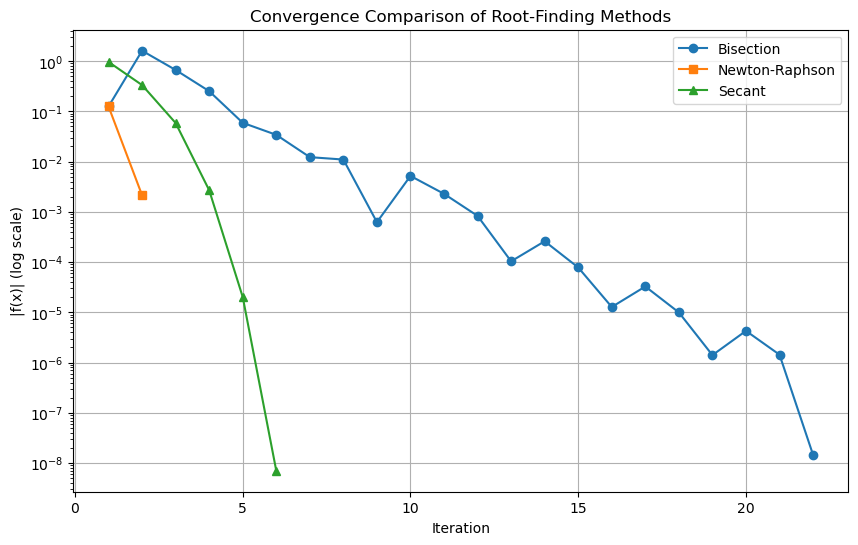

In [23]:
plt.figure(figsize=(10,6))

plt.plot(range(1, len(bisect_errors)+1), bisect_errors, marker='o', label="Bisection")
plt.plot(range(1, len(newton_errors)+1), newton_errors, marker='s', label="Newton-Raphson")
plt.plot(range(1, len(secant_errors)+1), secant_errors, marker='^', label="Secant")

plt.yscale("log")  # Important: log scale shows convergence clearly

plt.xlabel("Iteration")
plt.ylabel("|f(x)| (log scale)")
plt.title("Convergence Comparison of Root-Finding Methods")
plt.legend()
plt.grid(True)
plt.show()

# Final Comparative Analysis

## Bisection Method
- Guaranteed convergence when a sign-changing interval exists
- Most stable
- Slowest convergence
- Best when robustness is more important than speed

## Newton-Raphson Method
- Fastest convergence
- Requires derivative
- Sensitive to initial guess
- Best when derivative is known and starting point is good

## Secant Method
- Fast convergence without explicit derivative
- More efficient than Bisection
- Less robust than Bisection
- Strong practical compromise

## Overall Conclusion
For the test problem f(x)=x^3-x-2:

- Newton-Raphson was the fastest
- Secant provided near-Newton efficiency without derivative
- Bisection was the most reliable but slowest

This project demonstrates how different numerical methods balance stability, speed, and mathematical requirements.